# Fingerprint Gender Classification

**Dataset:** Sokoto Coventry Fingerprint Dataset (SOCOFing)
**Source:** [Kaggle — ruizgara/socofing](https://www.kaggle.com/datasets/ruizgara/socofing)

Submitted by: Abdullah Basit

##Step 1: Importing libraries

In [1]:
import os
import glob #Finds all files matching a pattern
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 #Loads images in grayscale and resizes them. This is the actual preprocessing step
from PIL import Image #Only used to peek at image size/mode and display sample images.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder #Converts "M"/"F" text labels into 0/1 numbers
from imblearn.combine import SMOTETomek #Fixes the male/female class imbalance in the training set


## Step 2: Download the dataset

This pulls the dataset straight from Kaggle. On Colab this works automatically the first time you're asked to sign in / provide your Kaggle API key.


In [2]:
import kagglehub
dataset_path = kagglehub.dataset_download("ruizgara/socofing")
print("Downloaded to:", dataset_path)

# We only need the folder with the original, unaltered fingerprints. SOCOFing also has an Altered folder for a different research task but we don't need it. So we will disregard it
real_dir = glob.glob(os.path.join(dataset_path, "**", "Real"), recursive=True)[0]

image_paths = glob.glob(os.path.join(real_dir, "*.BMP"))
print("Total images found:", len(image_paths))
print("Example filename:", os.path.basename(image_paths[0]))



100%|██████████| 838M/838M [00:08<00:00, 101MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2
Total images found: 6000
Example filename: 245__M_Left_ring_finger.BMP


## Step 3: Build a table of labels

Each filename already tells us the gender, e.g. `1__M_Left_index_finger.BMP` means Male.
We split the filename apart to pull out the label.


In [3]:
def get_gender_from_filename(path):
    filename = os.path.basename(path)
    # filename looks like: 1__M_Left_index_finger.BMP
    gender = filename.split("__")[1].split("_")[0]  # gives 'M' or 'F'
    return gender

data = []
for path in image_paths:
    gender = get_gender_from_filename(path)
    data.append({"filepath": path, "gender": gender})

df = pd.DataFrame(data)
print("Dataset shape (rows, columns):", df.shape)
df.head()


Dataset shape (rows, columns): (6000, 2)


,filepath,gender
0,/root/.cache/kagglehub/datasets/ruizgara/socof...,M
1,/root/.cache/kagglehub/datasets/ruizgara/socof...,M
2,/root/.cache/kagglehub/datasets/ruizgara/socof...,M
3,/root/.cache/kagglehub/datasets/ruizgara/socof...,M
4,/root/.cache/kagglehub/datasets/ruizgara/socof...,M


## Step 4: Understand the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  6000 non-null   object
 1   gender    6000 non-null   object
dtypes: object(2)
memory usage: 93.9+ KB
gender
M    4770
F    1230
Name: count, dtype: int64


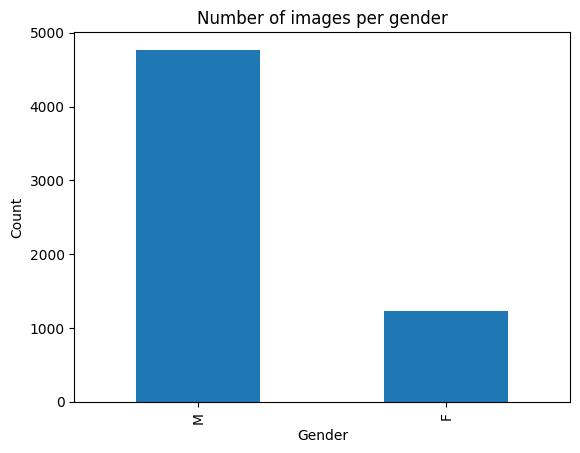

Missing values:
 filepath    0
gender      0
dtype: int64
Duplicate rows: 0


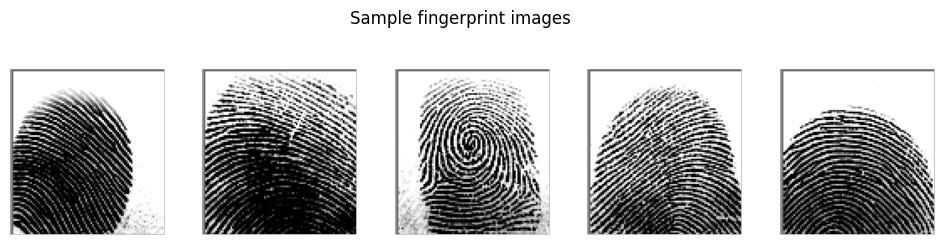

Image size: (96, 103) | Mode: RGBA


In [4]:
# Column data types
df.info()

# How many images per gender? (this is our target variable)
print(df["gender"].value_counts())

df["gender"].value_counts().plot(kind="bar", title="Number of images per gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Check for missing values
print("Missing values:\n", df.isna().sum())

# Check for duplicate rows (same filepath listed twice)
print("Duplicate rows:", df.duplicated().sum())

# Look at a few example fingerprint images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, path in zip(axes, df["filepath"].sample(5, random_state=1)):
    img = Image.open(path)
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.suptitle("Sample fingerprint images")
plt.show()

# Check the size of one image
sample_img = Image.open(df["filepath"].iloc[0])
print("Image size:", sample_img.size, "| Mode:", sample_img.mode)

## Step 5: Preprocess the images

For every image we will:
1. Resize it to a fixed size (96x96) so all images are the same shape
2. Convert it to grayscale (fingerprints are already grayscale, but we make sure)
3. Scale pixel values from 0-255 down to 0-1 (this helps the model train faster later)


In [5]:
IMG_SIZE = 96

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)          # load as grayscale
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))            # resize
    img = img.astype("float32") / 255.0                     # scale to 0-1
    return img

# Quick test on one image
test_img = preprocess_image(df["filepath"].iloc[0])
print("Processed image shape:", test_img.shape)
print("Pixel value range:", test_img.min(), "to", test_img.max())

# Now process every image in the dataset and stack them into one array
X = np.array([preprocess_image(p) for p in df["filepath"]])
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)   # add a channel dimension (needed for CNNs later)

print("Final image data shape:", X.shape)



Processed image shape: (96, 96)
Pixel value range: 0.0 to 1.0
Final image data shape: (6000, 96, 96, 1)


## Step 6: Encode the target label

Machine learning models need numbers, not letters. We convert "M"/"F" into 0/1.


In [6]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["gender"])

print("Label mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))


Label mapping: {'F': np.int64(0), 'M': np.int64(1)}


## Step 7: Split into train / validation / test sets

- **Train**: used to train the model
- **Validation**: used to tune the model while training
- **Test**: used only at the very end, to check final performance

We use stratify=y so each split keeps the same male/female ratio as the full dataset.


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape[0], "images")
print("Validation:", X_val.shape[0], "images")
print("Test:", X_test.shape[0], "images")


Train: 4200 images
Validation: 900 images
Test: 900 images


## Step 8: Handle class imbalance (SMOTE-Tomek)

SOCOFing has more male fingerprints than female ones. If we train on this as-is, the model may just learn to guess "male" most of the time. SMOTE-Tomek fixes this by creating new synthetic minority-class samples and removing borderline/noisy points, so both classes end up balanced.

**Important:** we only balance the training set. The validation and test sets stay untouched, because they need to represent the real world.


In [8]:
print("Before balancing:", np.bincount(y_train))

# SMOTE-Tomek needs flat (non-image-shaped) data, so we temporarily flatten each image
X_train_flat = X_train.reshape(X_train.shape[0], -1)

smote_tomek = SMOTETomek(random_state=42)
X_train_flat_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_flat, y_train)

# Reshape back into images
X_train_balanced = X_train_flat_balanced.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("After balancing:", np.bincount(y_train_balanced))


Before balancing: [ 861 3339]
After balancing: [3339 3339]


## Step 9: Save the preprocessed data

In [9]:
os.makedirs("preprocessed_data", exist_ok=True)

np.savez_compressed(
    "preprocessed_data/socofing_gender_preprocessed.npz",
    X_train=X_train_balanced, y_train=y_train_balanced,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
)

print("Saved! This file will be loaded in the next notebook to train the model.")


Saved! This file will be loaded in the next notebook to train the model.
